In [ ]:
# ==========================
# Imports
# ==========================
import os
import cv2
import math
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ==========================
# Mount and Extract (if needed)
# ==========================
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/alzheimer detection.v4-augmentation.folder.zip'
extract_path = '/content/alzheimer_detection_v4_augmented'

if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Dataset extracted to: {extract_path}")
else:
    print(f"✅ Dataset already extracted to: {extract_path}")

if os.path.exists(extract_path):
    print(f"✅ Data directory found at: {extract_path}")
    print("Contents:", os.listdir(extract_path))
else:
    print(f"❌ Data directory not found at: {extract_path}")


Mounted at /content/drive
✅ Dataset extracted to: /content/alzheimer_detection_v4_augmented
✅ Data directory found at: /content/alzheimer_detection_v4_augmented
Contents: ['README.roboflow.txt', 'README.dataset.txt', 'test', 'valid', 'train']


100%|██████████| 4/4 [00:00<00:00, 74.79it/s]
/tmp/ipython-input-2153013449.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df.label, palette='Set1')


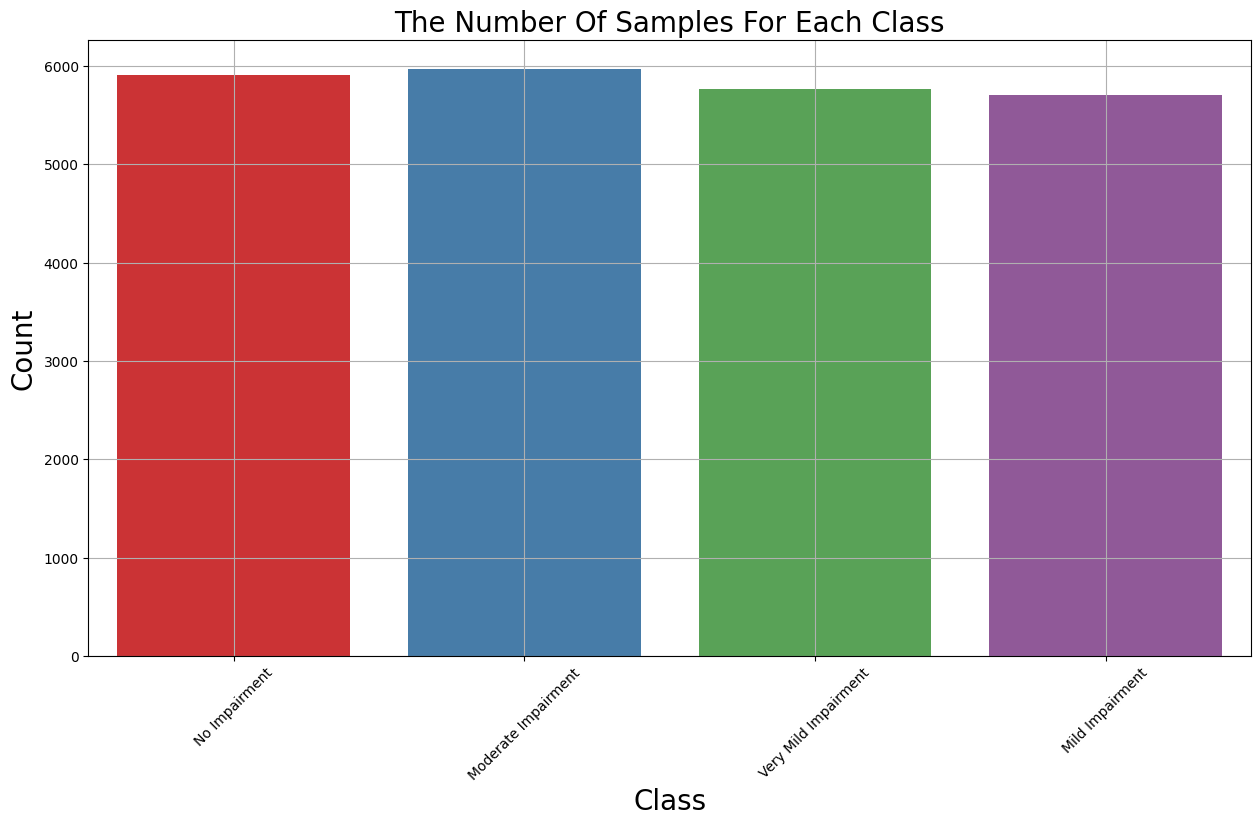

In [ ]:
# ==========================
# Prepare dataset
# ==========================
images = []
labels = []
data_path = '/content/alzheimer_detection_v4_augmented/train'

for class_folder in tqdm(os.listdir(data_path)):
    class_folder_path = os.path.join(data_path, class_folder)
    if not os.path.isdir(class_folder_path):
        continue
    for image_filename in os.listdir(class_folder_path):
        image_path = os.path.join(class_folder_path, image_filename)
        images.append(image_path)
        labels.append(class_folder)

df = pd.DataFrame({'image': images, 'label': labels})

plt.figure(figsize=(15, 8))
ax = sns.countplot(x=df.label, palette='Set1')
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class', fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# ==========================
# Split dataset
# ==========================
le = LabelEncoder()
labels_encoded = le.fit_transform(df['label'])
X = df['image'].values
y = labels_encoded

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [ ]:
# ==========================
# Dataset Class
# ==========================
class AlzheimerMRIDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(cv2.resize(image, (224, 224)), cv2.COLOR_BGR2RGB)
        image = image.astype('float32') / 255.0
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# ==========================
# Transforms and Dataloaders
# ==========================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = AlzheimerMRIDataset(X_train, y_train, transform=transform)
val_dataset = AlzheimerMRIDataset(X_val, y_val, transform=transform)
test_dataset = AlzheimerMRIDataset(X_test, y_test, transform=transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
# ==========================
# GhostNet Block
# ==========================
class GhostModule(nn.Module):
    def __init__(self, inp, oup, kernel_size=1, ratio=2, dw_size=3, stride=1, relu=True):
        super(GhostModule, self).__init__()
        self.oup = oup
        init_channels = math.ceil(oup / ratio)
        new_channels = init_channels * (ratio - 1)

        self.primary_conv = nn.Sequential(
            nn.Conv2d(inp, init_channels, kernel_size, stride,
                      kernel_size // 2, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True) if relu else nn.Sequential(),
        )

        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_channels, new_channels, dw_size, 1,
                      dw_size // 2, groups=init_channels, bias=False),
            nn.BatchNorm2d(new_channels),
            nn.ReLU(inplace=True) if relu else nn.Sequential(),
        )

    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        out = torch.cat([x1, x2], dim=1)
        return out[:, :self.oup, :, :]

# ==========================
# ResNet18 + GhostNet Head
# ==========================
class AlzheimerResNet18Ghost(nn.Module):
    def __init__(self, num_classes=4, ghost_out_channels=256):
        super(AlzheimerResNet18Ghost, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features  # 512

        # keep backbone up to global average pooling
        self.backbone.fc = nn.Identity()  # output: (B, 512)

        self.ghost = GhostModule(
            inp=in_features,
            oup=ghost_out_channels,
            kernel_size=1,
            ratio=2,
            dw_size=3,
            stride=1,
            relu=True
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # (B, C, 1, 1)
            nn.Flatten(),              # (B, C)
            nn.Linear(ghost_out_channels, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)                    # (B, 512)
        x = x.view(x.size(0), x.size(1), 1, 1)  # (B, 512, 1, 1)
        x = self.ghost(x)                       # (B, ghost_out_channels, 1, 1)
        x = self.classifier(x)                  # (B, num_classes)
        return x                                # logits


In [ ]:
# ==========================
# Training Setup
# ==========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlzheimerResNet18Ghost(num_classes=4, ghost_out_channels=256).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
epochs = 20

# ==========================
# Training Loop
# ==========================
for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in trainloader:
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(images)          # logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.max(outputs, 1)[1]
        train_correct += torch.sum(preds == labels.data)

    train_loss /= len(trainloader.dataset)
    train_acc = float(train_correct) / len(trainloader.dataset)

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device, dtype=torch.float)
            labels = labels.to(device, dtype=torch.long)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.max(outputs, 1)[1]
            val_correct += torch.sum(preds == labels.data)

    val_loss /= len(valloader.dataset)
    val_acc = float(val_correct) / len(valloader.dataset)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_resnet18_ghost.pt")

print("✅ Training Finished")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


Epoch 1/20 - Train Loss: 0.4989, Acc: 0.7868 | Val Loss: 0.5155, Acc: 0.7876
Epoch 2/20 - Train Loss: 0.3127, Acc: 0.8748 | Val Loss: 0.3654, Acc: 0.8590
Epoch 3/20 - Train Loss: 0.2042, Acc: 0.9237 | Val Loss: 0.2158, Acc: 0.9112
Epoch 4/20 - Train Loss: 0.1308, Acc: 0.9522 | Val Loss: 0.2024, Acc: 0.9283
Epoch 5/20 - Train Loss: 0.0926, Acc: 0.9659 | Val Loss: 0.4174, Acc: 0.8695
Epoch 6/20 - Train Loss: 0.0641, Acc: 0.9760 | Val Loss: 0.4179, Acc: 0.8747
Epoch 7/20 - Train Loss: 0.0602, Acc: 0.9782 | Val Loss: 0.1113, Acc: 0.9566
Epoch 8/20 - Train Loss: 0.0522, Acc: 0.9809 | Val Loss: 0.2133, Acc: 0.9321
Epoch 9/20 - Train Loss: 0.0457, Acc: 0.9842 | Val Loss: 0.1466, Acc: 0.9555
Epoch 10/20 - Train Loss: 0.0352, Acc: 0.9876 | Val Loss: 0.8243, Acc: 0.7668
Epoch 11/20 - Train Loss: 0.0313, Acc: 0.9897 | Val Loss: 0.2643, Acc: 0.9224
Epoch 12/20 - Train Loss: 0.0350, Acc: 0.9884 | Val Loss: 0.1198, Acc: 0.9580
Epoch 13/20 - Train Loss: 0.0356, Acc: 0.9887 | Val Loss: 0.2174, Acc: 0.

Confusion Matrix:
 [[834   0  12  11]
 [  1 894   0   0]
 [ 16   1 829  41]
 [ 26   0  70 769]]


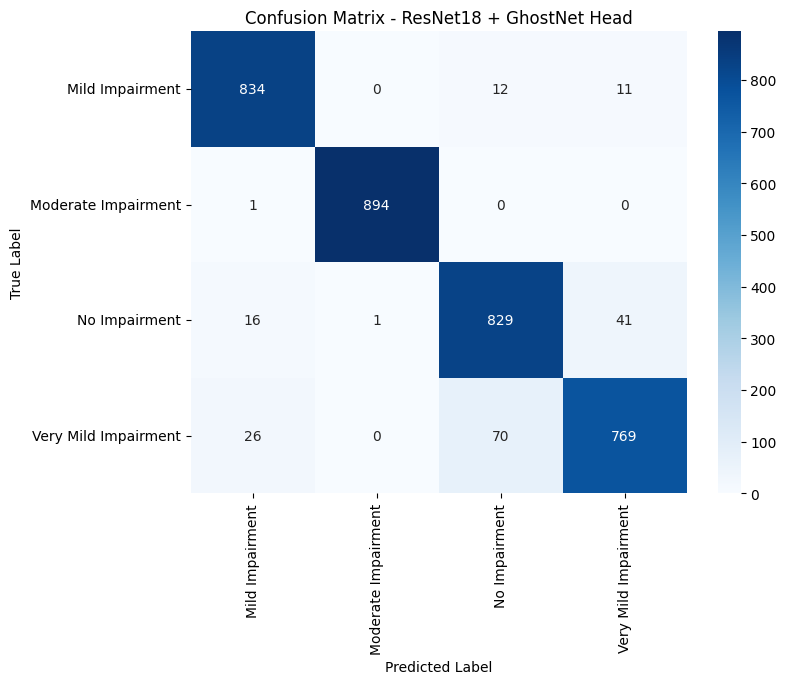

Classification Report:
                       precision    recall  f1-score   support

     Mild Impairment       0.95      0.97      0.96       857
 Moderate Impairment       1.00      1.00      1.00       895
       No Impairment       0.91      0.93      0.92       887
Very Mild Impairment       0.94      0.89      0.91       865

            accuracy                           0.95      3504
           macro avg       0.95      0.95      0.95      3504
        weighted avg       0.95      0.95      0.95      3504

Overall Accuracy: 0.9492
Balanced Accuracy: 0.9489

Per-Class Metrics:
Mild Impairment -> Precision: 0.9510, Recall: 0.9732, Specificity: 0.9838, F1: 0.9619
Moderate Impairment -> Precision: 0.9989, Recall: 0.9989, Specificity: 0.9996, F1: 0.9989
No Impairment -> Precision: 0.9100, Recall: 0.9346, Specificity: 0.9687, F1: 0.9221
Very Mild Impairment -> Precision: 0.9367, Recall: 0.8890, Specificity: 0.9803, F1: 0.9122


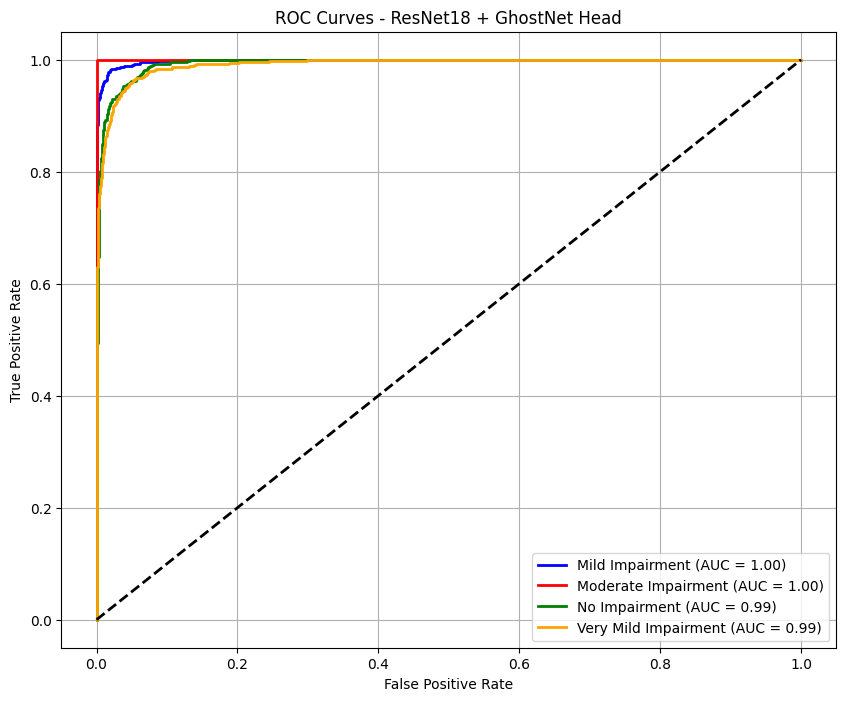


Class-wise Metrics:

Mild Impairment: TPR=0.9732, FPR=0.0162, TNR=0.9838, FNR=0.0268, ROC AUC=0.9982

Moderate Impairment: TPR=0.9989, FPR=0.0004, TNR=0.9996, FNR=0.0011, ROC AUC=1.0000

No Impairment: TPR=0.9346, FPR=0.0313, TNR=0.9687, FNR=0.0654, ROC AUC=0.9934

Very Mild Impairment: TPR=0.8890, FPR=0.0197, TNR=0.9803, FNR=0.1110, ROC AUC=0.9917


In [ ]:
# ==========================
# Evaluation
# ==========================
model.load_state_dict(torch.load('best_resnet18_ghost.pt', map_location=device))
model.eval()

preds, true_labels, probs = [], [], []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device, dtype=torch.float)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        softmax_probs = torch.softmax(outputs, dim=1)  # probabilities
        probabilities = softmax_probs.cpu().numpy()

        _, predicted = torch.max(outputs, 1)
        preds.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
        probs.extend(probabilities)

true_labels = np.array(true_labels)
preds = np.array(preds)
probs = np.array(probs)

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ResNet18 + GhostNet Head')
plt.show()

# Classification Report
print("Classification Report:\n",
      classification_report(true_labels, preds, target_names=le.classes_))

# Accuracy metrics
acc = accuracy_score(true_labels, preds)
bal_acc = balanced_accuracy_score(true_labels, preds)
print("Overall Accuracy:", round(acc, 4))
print("Balanced Accuracy:", round(bal_acc, 4))

# Per-class metrics
precision, recall, f1_score, support = precision_recall_fscore_support(
    true_labels, preds, average=None
)
print("\nPer-Class Metrics:")
for i, class_name in enumerate(le.classes_):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    print(f"{class_name} -> Precision: {precision[i]:.4f}, "
          f"Recall: {recall[i]:.4f}, Specificity: {specificity:.4f}, "
          f"F1: {f1_score[i]:.4f}")

# ROC-AUC for each class
n_classes = len(le.classes_)
y_true_bin = label_binarize(true_labels, classes=range(n_classes))
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(
        fpr[i], tpr[i], color=colors[i], lw=2,
        label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - ResNet18 + GhostNet Head')
plt.legend(loc="lower right")
plt.grid()
plt.show()

print("\nClass-wise Metrics:")
for i in range(n_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR_val = FP / (FP + TN) if (FP + TN) > 0 else 0
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
    FNR = FN / (TP + FN) if (TP + FN) > 0 else 0
    print(f"\n{le.classes_[i]}: TPR={TPR:.4f}, FPR={FPR_val:.4f}, "
          f"TNR={TNR:.4f}, FNR={FNR:.4f}, ROC AUC={roc_auc[i]:.4f}")
